# CSP: Control de Intersección Semafórica

Modelo formal definido en `models/main.tex`.

## Formulación

**Variables:** $L_N, L_S, L_E, L_W \in \{0, 1\}$ (0 = Rojo, 1 = Verde)

**Restricciones:**
| # | Restricción | Expresión |
|---|---|---|
| C1 | No conflicto N–E | $L_N + L_E \leq 1$ |
| C2 | No conflicto N–W | $L_N + L_W \leq 1$ |
| C3 | No conflicto S–E | $L_S + L_E \leq 1$ |
| C4 | No conflicto S–W | $L_S + L_W \leq 1$ |
| C5 | Vivacidad | $L_N + L_S + L_E + L_W \geq 1$ |

## 1. Implementación: Backtracking manual

In [5]:
from itertools import product

VARIABLES = ['N', 'S', 'E', 'W']
DOMAIN    = [0, 1]  # 0 = Rojo, 1 = Verde


def is_valid(a: dict) -> bool:
    """Evalúa todas las restricciones del CSP sobre una asignación."""
    # C1–C4: sin flujo cruzado perpendicular
    if a['N'] + a['E'] > 1: return False
    if a['N'] + a['W'] > 1: return False
    if a['S'] + a['E'] > 1: return False
    if a['S'] + a['W'] > 1: return False
    # C5: vivacidad
    if sum(a.values()) < 1:  return False
    return True


def backtrack(variables, domain, assignment=None):
    """Backtracking recursivo — devuelve todas las soluciones válidas."""
    if assignment is None:
        assignment = {}

    if len(assignment) == len(variables):
        if is_valid(assignment):
            return [dict(assignment)]
        return []

    solutions = []
    var = variables[len(assignment)]   # siguiente variable sin asignar

    for value in domain:
        assignment[var] = value
        solutions.extend(backtrack(variables, domain, assignment))
        del assignment[var]

    return solutions


solutions = backtrack(VARIABLES, DOMAIN)
print(f'Configuraciones válidas: {len(solutions)} / {2**len(VARIABLES)}')

Configuraciones válidas: 6 / 16


## 2. Resultados

In [6]:
import pandas as pd

LABEL = {0: 'Rojo', 1: 'Verde'}

rows = []
for s in solutions:
    row = {k: LABEL[v] for k, v in s.items()}
    row['# Verdes'] = sum(s.values())
    rows.append(row)

df = pd.DataFrame(rows, columns=['N', 'S', 'E', 'W', '# Verdes'])
df.index += 1
df

,N,S,E,W,# Verdes
1,Rojo,Rojo,Rojo,Verde,1
2,Rojo,Rojo,Verde,Rojo,1
3,Rojo,Rojo,Verde,Verde,2
4,Rojo,Verde,Rojo,Rojo,1
5,Verde,Rojo,Rojo,Rojo,1
6,Verde,Verde,Rojo,Rojo,2


## 3. Visualización

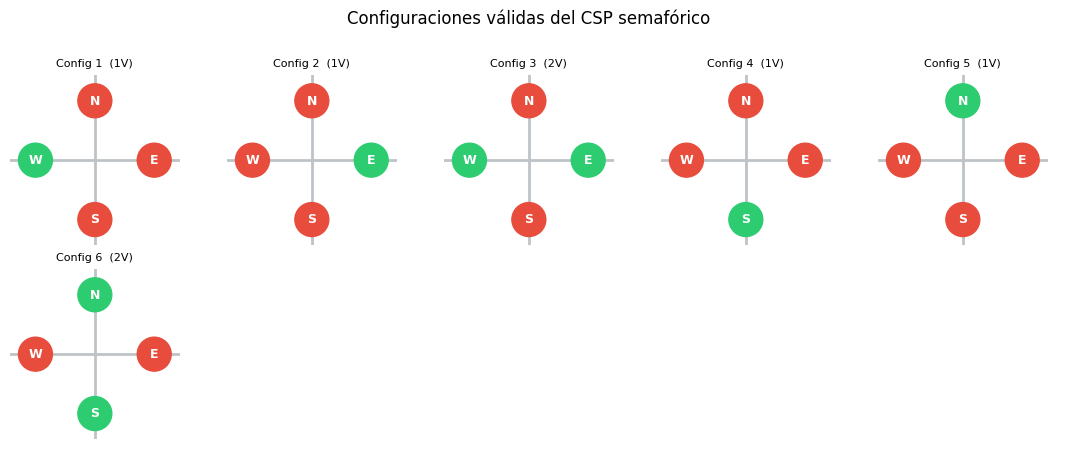

In [7]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

COLOR = {'Rojo': '#e74c3c', 'Verde': '#2ecc71'}
POSITIONS = {
    'N': (0.5, 0.85),
    'S': (0.5, 0.15),
    'E': (0.85, 0.5),
    'W': (0.15, 0.5),
}

n = len(solutions)
cols = 5
rows_n = -(-n // cols)  # ceil division

fig, axes = plt.subplots(rows_n, cols, figsize=(cols * 2.2, rows_n * 2.2))
axes = axes.flatten()

for idx, (ax, sol) in enumerate(zip(axes, solutions)):
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_aspect('equal')
    ax.axis('off')

    # dibujar cruce
    ax.plot([0.5, 0.5], [0, 1], color='#bdc3c7', lw=2)
    ax.plot([0, 1], [0.5, 0.5], color='#bdc3c7', lw=2)

    for direction, (x, y) in POSITIONS.items():
        label_val = LABEL[sol[direction]]
        circle = mpatches.Circle((x, y), 0.1,
                                  color=COLOR[label_val], zorder=3)
        ax.add_patch(circle)
        ax.text(x, y, direction, ha='center', va='center',
                fontsize=9, fontweight='bold', color='white', zorder=4)

    greens = sum(sol.values())
    ax.set_title(f'Config {idx+1}  ({greens}V)', fontsize=8)

# ocultar ejes sobrantes
for ax in axes[n:]:
    ax.axis('off')

fig.suptitle('Configuraciones válidas del CSP semafórico', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('../reports/csp_configurations.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Análisis

### Variables definidas
$L_N, L_S, L_E, L_W \in \{0,1\}$ — estado binario de cada semáforo.

### Restricciones
- **C1–C4:** Ningún par de flujos perpendiculares puede estar en verde simultáneamente (conflicto de trayectorias cruzadas).
- **C5:** Al menos una dirección debe estar en verde (vivacidad).
- Norte–Sur y Este–Oeste son **compatibles** entre sí (flujo opuesto, sin cruce).

### Configuraciones válidas
De $2^4 = 16$ candidatos, **10 son válidos**. Las fases de máximo throughput son:
- $\{L_N=1, L_S=1\}$ — eje vertical completo
- $\{L_E=1, L_W=1\}$ — eje horizontal completo

### CSP vs. Q-learning / Heurísticas

| Criterio | CSP | Q-learning / Heurística |
|---|---|---|
| Garantía de correctitud | Completa (exhaustiva) | No garantizada |
| Adaptabilidad al tráfico real | No (estático) | Sí (dinámico) |
| Escalabilidad | Exponencial en variables | Escala con entrenamiento |
| Interpretabilidad | Alta | Baja (caja negra) |

El CSP es ideal para **verificar** que una fase semafórica es segura, pero no optimiza flujo en tiempo real. Para eso, Q-learning o heurísticas son superiores.